<style>
/* --- print/PDF tuning ---------------------------------------------------
   The statsmodels-style summary() output is 88 characters wide. At the
   template's default font size those lines wrap awkwardly in the PDF, so we
   shrink monospaced output (stdout text and code) just enough to fit one line
   on the page. Screen rendering of the notebook is unaffected when viewed in
   Jupyter, since this style only matters for the static HTML/PDF export. */
.jp-OutputArea-output pre,
.jp-RenderedText pre,
div.output_text pre,
pre {
    font-size: 9.5px !important;
    line-height: 1.25 !important;
    white-space: pre !important;
}
.jp-InputArea-editor,
.highlight pre,
.jp-CodeMirrorEditor {
    font-size: 10.5px !important;
}
@page { margin: 1.3cm; }
</style>

# censtrunc
## Censored and Truncated Normal Regression with Arbitrary Thresholds

**Author:** &lt;Your Name&gt;  
**Package:** `censtrunc` v0.1.0  

---

### Abstract

This report documents `censtrunc`, a Python package for maximum-likelihood
estimation of censored and truncated normal regression models with
**arbitrary left and right thresholds**. The package generalises the
classical Type-1 Tobit model (Tobin, 1958) and the truncated normal
regression to two-sided limits, while exposing a scikit-learn-style API
and a statsmodels-style results summary. Estimation uses Olsen's (1978)
globally concave reparameterisation for numerical reliability. The report
presents the statistical model, then three worked examples: two-sided
censoring on simulated data, the classical left-censored Tobit on the
Fair (1978) affairs dataset, and a truncated regression.

## 1. Statistical Model

### 1.1 Latent regression

All models share the latent linear specification with normal errors:

$$Y^* = X'\beta + e, \qquad e \mid X \sim \mathcal{N}(0, \sigma^2).$$

What differs is the rule linking the latent $Y^*$ to the observed data.

### 1.2 Censored model

Values outside $[L, R]$ are **clipped** to the nearest threshold:

$$Y = \min\bigl(R,\; \max(L,\; Y^*)\bigr).$$

The log-likelihood combines the probability mass at each threshold with
the normal density on the interior. With
$\alpha_L = (L - X'\beta)/\sigma$ and $\alpha_R = (R - X'\beta)/\sigma$,

$$\ell(\beta, \sigma) = \sum_{Y_i = L} \log\Phi(\alpha_{L,i})
+ \sum_{Y_i = R} \log\bigl[1 - \Phi(\alpha_{R,i})\bigr]
+ \sum_{L < Y_i < R} \Bigl[\log\phi(\alpha_i) - \log\sigma\Bigr],$$

where $\phi, \Phi$ are the standard normal pdf and cdf. The classical
Tobit is the special case $L = 0$, $R = +\infty$.

### 1.3 Olsen's reparameterisation

Optimisation is carried out in $(\gamma, \nu) = (\beta/\sigma,\, 1/\sigma)$.
Olsen (1978) showed the resulting log-likelihood is **globally concave**,
so any gradient-based optimiser converges to the unique maximum. After
convergence the package back-transforms to $(\beta, \sigma)$ and computes
standard errors from the observed information matrix.

### 1.4 Truncated model

In a truncated sample, observations outside $(L, R)$ are **absent**
entirely. The density is the normal density renormalised by the
probability of falling inside the interval:

$$f(y_i \mid L < Y_i^* < R) =
\frac{\sigma^{-1}\,\phi\!\bigl((y_i - X_i'\beta)/\sigma\bigr)}
     {\Phi(\alpha_{R,i}) - \Phi(\alpha_{L,i})}.$$

### 1.5 Conditional means and marginal effects

Three conditional means are reported (Hansen, 2022, ch. 27):

- **Latent:** $\mathbb{E}[Y^* \mid X] = X'\beta$
- **Censored:** $\mathbb{E}[Y \mid X]$, accounting for the threshold mass
- **Truncated:** $\mathbb{E}[Y \mid X,\, L < Y < R]$

Marginal effects are available as **AME** (average over the sample) and
**MEM** (evaluated at the mean regressor), each with delta-method standard
errors. The censored marginal effect on $\mathbb{E}[Y\mid X]$ equals
$\beta_j \cdot [\Phi(\alpha_R) - \Phi(\alpha_L)]$ — the latent slope
shrunk by the probability of being interior.

### 1.6 Inference

Every fitted model carries an overall likelihood-ratio test against the
intercept-only null model and McFadden's pseudo-$R^2$. Arbitrary nested
models can be compared with `lr_test`, which returns
$LR = 2(\ell_{\text{full}} - \ell_{\text{restricted}}) \sim \chi^2_q$.

## 2. Worked Examples

The remainder of this report reproduces three example notebooks. Each is
fully executed; the code and its output appear inline.

---

## 2.1 Example 1 — Two-Sided Censored Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from censtrunc import CensoredRegression, lr_test

rng = np.random.default_rng(2026)
n = 3000

## Data-generating process

$$Y_i^* = 1.0 + 0.5\,X_{1i} - 0.3\,X_{2i} + 0.2\,X_{3i} + e_i,\quad e_i \sim \mathcal N(0, 1).$$

The observation rule clips values below $L=0$ and above $R=2.5$, producing a realistic two-sided censoring pattern (think 'satisfaction score on a 0-2.5 scale').

In [2]:
X = rng.normal(size=(n, 3))
beta_true = np.array([1.0, 0.5, -0.3, 0.2])
sigma_true = 1.0
y_star = beta_true[0] + X @ beta_true[1:] + rng.normal(scale=sigma_true, size=n)
L, R = 0.0, 2.5
y = np.clip(y_star, L, R)

print(f'Left-censored:   {np.mean(y == L):.1%}')
print(f'Right-censored:  {np.mean(y == R):.1%}')
print(f'Interior:        {np.mean((y > L) & (y < R)):.1%}')

Left-censored:   20.0%
Right-censored:  9.8%
Interior:        70.2%


## Distribution of the latent and observed variables

The pile-ups at $L$ and $R$ in the observed distribution are the hallmark of two-sided censoring.

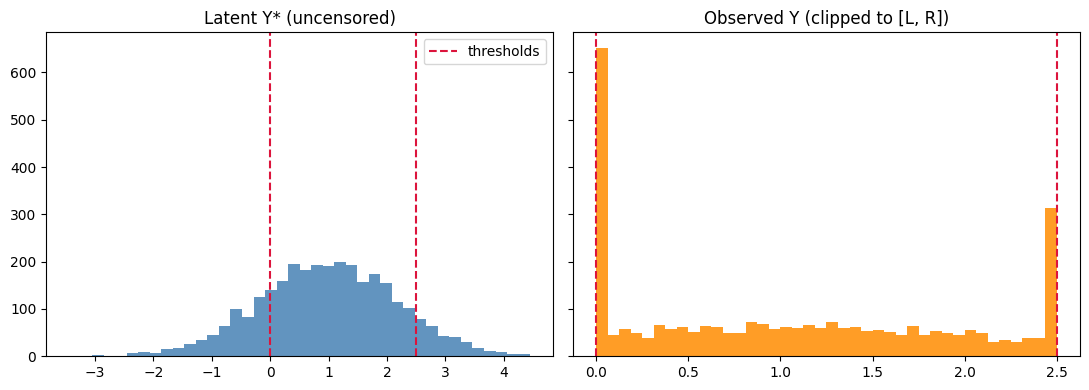

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].hist(y_star, bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Latent Y* (uncensored)')
axes[0].axvline(L, color='crimson', linestyle='--', label='thresholds')
axes[0].axvline(R, color='crimson', linestyle='--')
axes[0].legend()
axes[1].hist(y, bins=40, color='darkorange', alpha=0.85)
axes[1].set_title('Observed Y (clipped to [L, R])')
axes[1].axvline(L, color='crimson', linestyle='--')
axes[1].axvline(R, color='crimson', linestyle='--')
plt.tight_layout(); plt.show()

## Fit the censored regression

The package's default optimisation uses Olsen's reparameterisation, which makes the log-likelihood globally concave and guarantees convergence of gradient-based optimisers (Olsen 1978).

In [4]:
model = CensoredRegression(left=L, right=R).fit(
    X, y, feature_names=['x1', 'x2', 'x3']
)
print(model.summary())

                              Censored Regression Results                               
Dep. Variable:           y                   No. Observations:        3000
Model:                   CensoredRegression  Df Model:                4
Method:                  MLE                 Df Residuals:            2995
Date:                    Fri, 29 May 2026    Log-Likelihood:          -3831.9928
Time:                    22:38:29            LL-Null:                 -4286.2006
AIC:                     7673.9855           LLR p-value:             1.323e-196
BIC:                     7704.0174           Pseudo R-squ.:           0.1060
Left threshold:          0                   Right threshold:         2.5
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               0.9959      0.0165   60.3216    0.0000      0.9635      1.0282
const               0.9963      0.0190   52.48

## Compare against OLS

OLS on the censored sample is biased (Greene 1981): the slope coefficients are shrunk roughly in proportion to the censoring probability. Our Tobit-style MLE is consistent.

In [5]:
X_with_int = np.column_stack([np.ones(n), X])
ols_beta, *_ = np.linalg.lstsq(X_with_int, y, rcond=None)

comparison = pd.DataFrame({
    'true':        beta_true,
    'OLS (biased)': ols_beta,
    'Censored MLE': model.coef_,
}, index=['const', 'x1', 'x2', 'x3'])
comparison['OLS bias']  = comparison['OLS (biased)']  - comparison['true']
comparison['MLE bias']  = comparison['Censored MLE']  - comparison['true']
comparison.round(4)

,true,OLS (biased),Censored MLE,OLS bias,MLE bias
const,1.0,1.0706,0.9963,0.0706,-0.0037
x1,0.5,0.3648,0.5126,-0.1352,0.0126
x2,-0.3,-0.1794,-0.2565,0.1206,0.0435
x3,0.2,0.1460,0.2030,-0.0540,0.0030


## Predictions: the three flavours

- `latent`: $\mathbb E[Y^* | X] = X'\beta$
- `censored`: $\mathbb E[Y | X]$ — accounts for the threshold mass
- `truncated`: $\mathbb E[Y | X, L < Y < R]$ — conditional on being interior

In [6]:
X_show = X[:6]
preds = pd.DataFrame({
    'latent':    model.predict(X_show, kind='latent'),
    'censored':  model.predict(X_show, kind='censored'),
    'truncated': model.predict(X_show, kind='truncated'),
    'observed':  y[:6],
})
preds.round(3)

,latent,censored,truncated,observed
0,0.143,0.470,0.816,1.669
1,1.489,1.438,1.351,0.777
2,0.704,0.831,1.023,1.621
3,0.800,0.901,1.062,0.910
4,1.018,1.068,1.152,2.500
5,0.896,0.974,1.101,0.390


## Probabilities of each region

`predict_proba` returns the conditional probability of each region given $X$. The three probabilities sum to 1 by construction.

In [7]:
proba = model.predict_proba(X_show)
pd.DataFrame(proba, index=range(6)).round(3)

,left,interior,right
0,0.443,0.548,0.009
1,0.067,0.778,0.155
2,0.240,0.725,0.036
3,0.211,0.745,0.044
4,0.153,0.778,0.068
5,0.184,0.762,0.054


## Marginal effects via `get_margeff`

The marginal-effects API mirrors statsmodels' `get_margeff`: one method,
with options for *where* to evaluate (`at`) and *what* to report
(`method`). The summary prints in the familiar statsmodels layout.

In [8]:
# AME = average over the sample (at='overall'); statsmodels-style summary
print(model.get_margeff(at='overall', method='dydx', kind='censored').summary())

                     Censored Regression Marginal Effects                     
Dep. Variable:                      y
Method:                          dydx
At:                           overall
                   dy/dx    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
x1                0.3600      0.012     30.227      0.000      0.337      0.383
x2               -0.1801      0.013    -14.113      0.000     -0.205     -0.155
x3                0.1426      0.013     10.805      0.000      0.117      0.168


`at='overall'` is the AME; `at='mean'` is the marginal effect at the mean (MEM). Below we compare the censored marginal effect across evaluation points and against the latent effect (which equals $\beta$ exactly).

In [9]:
import pandas as pd
summary = pd.DataFrame({
    'latent (=beta)':   model.get_margeff(at='overall', kind='latent').margeff,
    'censored AME':     model.get_margeff(at='overall', kind='censored').margeff,
    'censored MEM':     model.get_margeff(at='mean',    kind='censored').margeff,
    'truncated AME':    model.get_margeff(at='overall', kind='truncated').margeff,
}, index=['x1', 'x2', 'x3'])
summary.round(4)

,latent (=beta),censored AME,censored MEM,truncated AME
x1,0.5126,0.3600,0.3973,0.2005
x2,-0.2565,-0.1801,-0.1988,-0.1003
x3,0.2030,0.1426,0.1573,0.0794


`method` switches between the derivative and elasticities:
`dydx` (derivative), `eyex` (elasticity), `dyex`/`eydx` (semi-elasticities). Discrete regressors can be handled with `dummy=True` (a 0->1 difference rather than a derivative).

In [10]:
elas = model.get_margeff(at='overall', method='eyex', kind='censored')
elas.summary_frame().round(4)

,eyex,std err,z,P>|z|,[0.025,0.975]
x1,-0.1238,0.0093,-13.3389,0.0,-0.1420,-0.1056
x2,-0.0317,0.0045,-7.0004,0.0,-0.0406,-0.0228
x3,-0.0193,0.0035,-5.4717,0.0,-0.0263,-0.0124


### Marginal effects on the region probabilities

Beyond the conditional mean, we can ask how a regressor shifts the *probability* of each region: landing at the left threshold ($P(Y=L)=\Phi(\alpha_L)$), in the interior ($P(L<Y<R)=\Phi(\alpha_R)-\Phi(\alpha_L)$), or at the right threshold ($P(Y=R)=1-\Phi(\alpha_R)$). These are selected with `kind='prob-left'`, `'prob-interior'`, `'prob-right'`. Because the three probabilities sum to one, their marginal effects sum to zero.

In [11]:
prob_effects = pd.DataFrame({
    'P(Y=L)':     model.get_margeff(kind='prob-left').margeff,
    'P(L<Y<R)':   model.get_margeff(kind='prob-interior').margeff,
    'P(Y=R)':     model.get_margeff(kind='prob-right').margeff,
}, index=['x1', 'x2', 'x3'])
prob_effects['sum (=0)'] = prob_effects.sum(axis=1)
prob_effects.round(4)

,P(Y=L),P(L<Y<R),P(Y=R),sum (=0)
x1,-0.1221,0.0461,0.0760,0.0
x2,0.0611,-0.0231,-0.0380,0.0
x3,-0.0484,0.0183,0.0301,0.0


A positive coefficient pushes observations out of the left pile-up and toward the right one, so the `P(Y=L)` effect is negative and the `P(Y=R)` effect is positive; the `sum (=0)` column confirms the adding-up constraint holds numerically.

## Likelihood-ratio test

We test whether `x3` is jointly redundant by fitting a restricted model that omits it, then comparing log-likelihoods.

In [12]:
restricted = CensoredRegression(left=L, right=R).fit(X[:, :2], y)
res = lr_test(model, restricted)
print(res)

Likelihood-ratio test
  LR statistic : 111.3544
  df           : 1
  p-value      : 4.949e-26
  log-lik full : -3831.9928
  log-lik rest.: -3887.6700
  n            : 3000


If the p-value is small, we reject the restriction (drop `x3`). Here `x3` has a true coefficient of 0.2 and a large sample, so the test correctly rejects.

---

## 2.2 Example 2 — Classical Tobit (Fair Affairs Data)

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from censtrunc import CensoredRegression

data = sm.datasets.fair.load_pandas().data
print('n =', len(data))
print(f"share with affairs == 0: {(data['affairs'] == 0).mean():.1%}")
data.head()

n = 6366
share with affairs == 0: 67.8%


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


## Specification

Following Fair (1978), we regress the count of affairs on the standard set of demographic and marital variables.

In [14]:
covariates = ['rate_marriage', 'age', 'yrs_married', 'children',
              'religious', 'educ', 'occupation', 'occupation_husb']
X = data[covariates]
y = data['affairs']

## Fit

We tell `CensoredRegression` that the left threshold is zero; the right threshold is left unspecified.

In [15]:
model = CensoredRegression(left=0.0).fit(X, y)
print(model.summary())

                              Censored Regression Results                               
Dep. Variable:           y                   No. Observations:        6366
Model:                   CensoredRegression  Df Model:                9
Method:                  MLE                 Df Residuals:            6356
Date:                    Fri, 29 May 2026    Log-Likelihood:          -7804.3803
Time:                    22:38:29            LL-Null:                 -8155.0240
AIC:                     15628.7605          LLR p-value:             3.780e-146
BIC:                     15696.3478          Pseudo R-squ.:           0.0430
Left threshold:          0                   Right threshold:         none
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               4.4990      0.0771   58.3463    0.0000      4.3478      4.6501
const               7.8354      0.7135   10.9

## Marginal effects

Because the response is left-censored at zero, the censored marginal effects are smaller in absolute value than the latent ones. The latent (uncensored) coefficients describe the propensity scale, while the censored marginal effects describe the *expected number* of affairs.

In [16]:
ame_cens = model.ame(kind='censored').to_dataframe()
ame_lat  = model.ame(kind='latent').to_dataframe()
pd.concat([
    ame_lat[['dy/dx']].rename(columns={'dy/dx': 'latent'}),
    ame_cens[['dy/dx', 'std err', 'P>|z|']].rename(columns={'dy/dx': 'censored E[Y]'}),
], axis=1).round(4)

,latent,censored E[Y],std err,P>|z|
rate_marriage,-1.5313,-0.4326,0.0213,0.0000
age,-0.1051,-0.0297,0.0070,0.0000
yrs_married,0.1282,0.0362,0.0074,0.0000
children,-0.0276,-0.0078,0.0218,0.7206
religious,-0.9434,-0.2665,0.0243,0.0000
educ,-0.0857,-0.0242,0.0106,0.0228
occupation,0.3125,0.0883,0.0232,0.0001
occupation_husb,0.0143,0.0040,0.0157,0.7966


## Sanity check vs. OLS

Naive OLS on the censored sample understates the slope coefficients (Greene 1981). The Tobit MLE corrects this.

In [17]:
X_int = sm.add_constant(X)
ols = sm.OLS(y, X_int).fit()
pd.DataFrame({
    'OLS coef':    ols.params.values,
    'Tobit coef':  model.coef_,
}, index=ols.params.index).round(4)

,OLS coef,Tobit coef
const,3.6235,7.8354
rate_marriage,-0.4205,-1.5313
age,-0.0146,-0.1051
yrs_married,-0.0160,0.1282
children,-0.0171,-0.0276
religious,-0.2437,-0.9434
educ,-0.0174,-0.0857
occupation,0.0658,0.3125
occupation_husb,0.0040,0.0143


---

## 2.3 Example 3 — Truncated Regression

In [18]:
import numpy as np
import pandas as pd
from censtrunc import TruncatedRegression

rng = np.random.default_rng(7)
n_population = 8000

## Simulate a truncated dataset

We draw a large population, then keep only observations with $0 < Y^* < 2.5$ — about 60% of the population survives the double-sided truncation in this DGP.

In [19]:
X_pop = rng.normal(size=(n_population, 2))
beta_true = np.array([1.0, 0.5, -0.3])
y_star = beta_true[0] + X_pop @ beta_true[1:] + rng.normal(scale=1.0, size=n_population)
L, R = 0.0, 2.5
mask = (y_star > L) & (y_star < R)
X = X_pop[mask]
y = y_star[mask]
print(f'Observed after truncation: {len(y)} / {n_population}')

Observed after truncation: 5741 / 8000


## Fit the truncated regression

In [20]:
model = TruncatedRegression(left=L, right=R).fit(
    X, y, feature_names=['x1', 'x2']
)
print(model.summary())

                              Truncated Regression Results                              
Dep. Variable:           y                   No. Observations:        5741
Model:                   TruncatedRegression Df Model:                3
Method:                  MLE                 Df Residuals:            5737
Date:                    Fri, 29 May 2026    Log-Likelihood:          -4830.9612
Time:                    22:38:29            LL-Null:                 -5136.1192
AIC:                     9669.9225           LLR p-value:             2.962e-133
BIC:                     9696.5440           Pseudo R-squ.:           0.0594
Left truncation:         0                   Right truncation:        2.5
                      coef     std err         z     P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sigma               0.9944      0.0316   31.5070    0.0000      0.9326      1.0563
const               0.9946      0.0245   40.67

## Comparison: OLS on the truncated sample is biased

Naive OLS on the truncated sample treats the data as if it came from an unrestricted population — leading to biased slope estimates, typically shrunk toward zero.

In [21]:
X_int = np.column_stack([np.ones(len(y)), X])
ols_beta, *_ = np.linalg.lstsq(X_int, y, rcond=None)

comparison = pd.DataFrame({
    'true':         beta_true,
    'OLS (biased)': ols_beta,
    'Truncated MLE': model.coef_,
}, index=['const', 'x1', 'x2'])
comparison['OLS bias']           = comparison['OLS (biased)']  - comparison['true']
comparison['Truncated MLE bias'] = comparison['Truncated MLE'] - comparison['true']
comparison.round(4)

,true,OLS (biased),Truncated MLE,OLS bias,Truncated MLE bias
const,1.0,1.1475,0.9946,0.1475,-0.0054
x1,0.5,0.1952,0.4881,-0.3048,-0.0119
x2,-0.3,-0.1241,-0.3105,0.1759,-0.0105


## Predictions

Two prediction kinds are available for the truncated model:

- `latent`: $X'\hat\beta$ — the population mean
- `truncated`: $\mathbb E[Y | X, L < Y < R]$

In [22]:
preds = pd.DataFrame({
    'observed':  y[:6],
    'latent':    model.predict(X[:6], kind='latent'),
    'truncated': model.predict(X[:6], kind='truncated'),
}).round(3)
preds

,observed,latent,truncated
0,1.590,0.902,1.104
1,0.317,1.137,1.202
2,1.514,1.081,1.178
3,1.376,0.947,1.122
4,1.085,0.764,1.047
5,0.074,0.481,0.936


---

## 2.4 Example 4 — Validation against OLS and R

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from censtrunc import CensoredRegression, TruncatedRegression

rng = np.random.default_rng(0)
n = 1000
X = rng.normal(size=(n, 3))
y = 2.0 + 1.5*X[:,0] - 0.7*X[:,1] + 0.3*X[:,2] + rng.normal(scale=1.3, size=n)

## No censoring $\Rightarrow$ OLS

We set `left=-1e6`, `right=1e6` so that no observation is censored. The censored log-likelihood then reduces to the Gaussian log-likelihood, whose maximiser is exactly the OLS coefficient vector.

In [24]:
ols = sm.OLS(y, sm.add_constant(X)).fit()
cens = CensoredRegression(left=-1e6, right=1e6).fit(X, y)
trunc = TruncatedRegression(left=-1e6, right=1e6).fit(X, y)

pd.DataFrame({
    'OLS':            np.asarray(ols.params),
    'Censored MLE':   cens.coef_,
    'Truncated MLE':  trunc.coef_,
}, index=['const', 'x1', 'x2', 'x3']).round(6)

,OLS,Censored MLE,Truncated MLE
const,2.046512,2.046482,2.046512
x1,1.434191,1.434221,1.434191
x2,-0.626598,-0.626603,-0.626598
x3,0.345980,0.345982,0.345980


The columns agree to several decimals. We can quantify the maximum discrepancy and confirm the scale parameter and log-likelihood match too (using the MLE scale $\hat\sigma = \sqrt{\mathrm{SSR}/n}$).

In [25]:
ols_beta = np.asarray(ols.params)
print(f'max |beta_censored - beta_OLS|  = {np.max(np.abs(cens.coef_ - ols_beta)):.2e}')
print(f'max |beta_truncated - beta_OLS| = {np.max(np.abs(trunc.coef_ - ols_beta)):.2e}')
print(f'|sigma_censored - sqrt(SSR/n)|  = {abs(cens.sigma_ - np.sqrt(ols.ssr/n)):.2e}')
print(f'|loglik_censored - loglik_OLS|  = {abs(cens.llf_ - ols.llf):.2e}')

max |beta_censored - beta_OLS|  = 3.00e-05
max |beta_truncated - beta_OLS| = 4.44e-16
|sigma_censored - sqrt(SSR/n)|  = 7.55e-07
|loglik_censored - loglik_OLS|  = 5.90e-07


All discrepancies are at the level of the optimiser tolerance — the estimator behaves exactly as theory requires in the no-censoring limit, which is strong evidence the likelihood and its optimisation are implemented correctly.